# Modelo Base y Modelo Predictivo

Este notebook parte de `train.csv` y `test.csv` que contienen las variables numéricas estandarizadas y las variables categóricas codificadas.

## Imports
---

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report, PrecisionRecallDisplay, average_precision_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


### Explicación de los Imports

Antes de trabajar con los datos se importan las librerías necesarias:

- **`numpy`:** librería base de Python para hacer cálculos numéricos rápidos. En este notebook la mayoría de las demás librerías la usa por debajo.

- **`pandas`:** permite trabajar con los datos en forma de tablas. En este notebook, se usa para cargar los archivos `train.csv` y `test.csv`, y organizar resultados.

- **`matplotlib.pyplot` y `seaborn`:** librerías para hacer gráficos. `seaborn` se construye sobre `matplotlib` y da gráficos con mejor apariencia por defecto.

- **`DummyClassifier`:** modelo que se usa como punto de comparación para el modelo base. No aprende nada de los datos, solo aplica reglas simples.

- **`LogisticRegression`, `RandomForestClassifier`, `GradientBoostingClassifier`:** tres algoritmos de la librería `scikit-learn` que se van a comparar entre sí en la sección del modelo predictivo.

- **`XGBClassifier`:** algoritmo de clasificación muy popular en competencias de Kaggle por su buen desempeño en datos tabulares.

- **`StratifiedKFold`, `cross_validate`, `GridSearchCV`:** herramientas de `scikit-learn` para evaluar modelos de forma confiable y para buscar automáticamente la mejor configuración de un modelo.

- **Métricas (`accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `roc_auc_score`, `confusion_matrix`, `ConfusionMatrixDisplay`, `RocCurveDisplay`, `classification_report`, `PrecisionRecallDisplay`, `average_precision_score`):** funciones que calculan qué tan bien está funcionando un modelo, cada una midiendo un aspecto distinto del desempeño.

### Justificación de RANDOM_STATE
Muchos de los procesos que vamos a usar tienen un componente de aleatoriedad interno, lo que significa que, si se ejecuta el mismo código dos veces, se podrían obtener resultados ligeramente distintos cada vez, lo cual va en contra de la reproducibilidad.

La solución a este problema es usar una semilla aleatoria con un número fijo, lo que garantizará que siempre que se use la misma semilla, el resultado de un proceso sea siempre idéntico entre una ejecución y otra.

## Carga de los Datos ya Procesados
---

En esta celda se cargan los archivos `train.csv` y `test.csv` obtenidos anteriormente, y se separan en dos partes cada uno:

- **`X`:** tabla con todas las variables predictoras.

- **`y`:** columna `Churn`, es decir, la respuesta correcta que el modelo debe aprender a predecir.

In [6]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# Separar las variables predictoras y la variable objetivo
X_train = train.drop(columns=["Churn"])
y_train = train["Churn"]
X_test = test.drop(columns=["Churn"])
y_test = test["Churn"]

print("Tamaño de entrenamiento (X_train):", X_train.shape, " | Tamaño de prueba (X_test):", X_test.shape)
print("Proporción de clientes que se van (Churn) en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))

Tamaño de entrenamiento (X_train): (5634, 45)  | Tamaño de prueba (X_test): (1409, 45)
Proporción de clientes que se van (Churn) en entrenamiento:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


### Interpretación de los Resultados
El resultado obtenido muestra que el conjunto de entrenamiento tiene 5634 clientes y 45 variables predictoras, y, que el de prueba tiene 1409 clientes con esas mismas variables. La proporción de la clase `Churn` (0 = se queda, 1 = abandona el servicio) es de aproximadamente 73.5% / 26.5%, es decir, el dataset está desbalanceado: hay casi 3 clientes que se quedan por cada uno que se va.

Este desbalance no es un problema que haya que arreglar obligatoriamente, pero sí es algo que hay que tener muy presente durante todo este notebook, porque cambia por completo qué significa que un modelo sea "bueno". Por ejemplo: un modelo que nunca identificara a ningún cliente que se va tendría igual un 73.5% de aciertos generales (*accuracy*), y eso sonaría bien en un primer vistazo, pero sería completamente inútil para el objetivo real del proyecto que es anticipar la fuga de clientes.

Por esa razón, a lo largo del notebook se usan varias métricas en conjunto y la elegida como criterio principal de comparación entre modelos es el **F1-score de la clase `Churn = 1`**, que resume en un solo número qué tan bien el modelo equilibra dos cosas: no dejar pasar clientes en riesgo (recall) y no generar demasiadas falsas alarmas (precision).



## Modelo Base (baseline)
---

Antes de construir un modelo predictivo, se construye uno extremadamente simple que no aprende nada de los patrones de los datos. Su función no es predecir bien, sino servir como punto de comparación mínimo. La pregunta que responde esta sección es: **"si el modelo predictivo que construyamos no logra superar claramente a esta regla tan simple, ¿realmente vale la pena usar Machine Learning para este problema?"**

`scikit-learn` ofrece un `DummyClassifier` con tres estrategias distintas:

1. **`most_frequent`:** siempre predice la clase que más se repite en los datos de entrenamiento. En este caso, siempre predeciría `Churn = No`.

2. **`stratified`:** genera predicciones al azar, pero respetando las proporciones reales de cada clase, es decir, predice "abandona el servicio" aproximadamente el 26.5% de las veces, al azar.

3. **`uniform`:** genera predicciones completamente al azar, con 50% de probabilidad para cada clase, sin tener en cuenta cuál es más común.

A continuación se calculan y comparan las tres, para elegir cuál es el baseline más adecuado.


In [7]:
estrategias = ["most_frequent", "stratified", "uniform"]
resumen_estrategias = []

# Se entrena y evalúa un DummyClassifier para cada estrategia
for estrategia in estrategias:
  dummy = DummyClassifier(strategy=estrategia, random_state=RANDOM_STATE)
  dummy.fit(X_train, y_train)
  y_pred_d = dummy.predict(X_test)
  y_proba_d = dummy.predict_proba(X_test)[:, 1]
  
  resumen_estrategias.append({
    "estrategia": estrategia,
    "accuracy": accuracy_score(y_test, y_pred_d),
		"precision": precision_score(y_test, y_pred_d, zero_division=0),
		"recall": recall_score(y_test, y_pred_d, zero_division=0),
		"f1": f1_score(y_test, y_pred_d, zero_division=0),
		"roc_auc": roc_auc_score(y_test, y_proba_d),
  })

pd.DataFrame(resumen_estrategias).set_index("estrategia").round(3)

,accuracy,precision,recall,f1,roc_auc
estrategia,,,,,
most_frequent,0.735,0.000,0.000,0.00,0.500
stratified,0.622,0.289,0.291,0.29,0.516
uniform,0.487,0.252,0.476,0.33,0.500


### Interpretación de la Tabla
Cada fila es una de las tres estrategias y cada columna es una métrica distinta:

- **accuracy:** porcentaje total de aciertos.

- **precision:** de los clientes que el modelo dijo que se iban, cuántos realmente se fueron.

- **recall:** de los clientes que realmente se fueron, cuántos detectó el modelo.

- **f1:** combina precision y recall en un solo número.

- **roc_auc:** mide qué tan bien distingue el modelo entre ambas clases en general, donde 0.5 equivale a adivinar al azar.

### Interpretación de los Resultados
`most_frequent` obtiene el mejor *accuracy* (~ 73%), pero su *precision*, *recall* y *f1* son exactamente 0, porque, al predecir siempre "No" para todos los clientes, nunca acierta ni una sola vez con los que sí se van.

Las otras dos estrategias (`stratified` y `uniform`) sí llegan a acertar algunos casos de churn por pura casualidad, pero a costa de un *accuracy* mucho más bajo y sin una capacidad predictiva real, ya que su *roc_auc* ronda 0.5, el valor esperado de una predicción aleatoria.

### Elección del Baseline
Se elige `most_frequent` como baseline oficial, ya que, aunque suene contradictorio elegir la estrategia que "más falla" en detectar clientes en riesgo, es justamente la comparación más exigente y realista: el costo de no tener ningún modelo en la empresa hoy, es decir, asumir que nadie se va y no hacer nada al respecto.

## Modelo Predictivo
---

### Entrenamiento del Modelo
---

Se comparan cuatro algoritmos candidatos razonables para un problema de clasificación binaria tabular:

- **Regresión Logística:** es el modelo más simple de los cuatro. Traza una especie de línea de decisión basada en una combinación lineal de las variables. Se incluye como punto de referencia ya que es rápido de entrenar y fácil de interpretar.

- **Random Forest:** en lugar de entrenar un solo modelo, entrena muchos árboles de decisión distintos y promedia sus predicciones. A diferencia de la Regresión Logística, puede capturar relaciones no lineales e interacciones entre variables, además, no necesita que los datos estén perfectamente escalados.

- **Gradient Boosting:** combina muchos árboles, pero de forma distinta a Random Forest, pues los construye uno detrás del otro y cada árbol nuevo intenta corregir específicamente los errores que cometieron los anteriores.

- **XGBoost:** es una versión optimizada del mismo principio de Gradient Boosting. Se incluye como cuarto candidato porque, siendo del mismo estilo que Gradient Boosting pero con una implementación distinta, permite verificar si esa optimización realmente marca una diferencia.

Si solo se entrenara cada modelo una vez con un único split de datos, el resultado podría depender en parte de la suerte. Por ello, la comparación inicial se hace con validación cruzada estratificada, ya que divide el conjunto de entrenamiento en varias partes llamadas *folds*, entrena y evalua el modelo varias veces y promedia los resultados. Esto da una estimación mucho más confiable de qué tan bien generaliza el modelo, en vez de depender de un solo intento.

Se usa específicamente la variante estratificada porque, al estar el dataset desbalanceado (~ 26.5% de clientes abandonan el servicio), una división completamente al azar podría dejar un fold con muy pocos casos de churn, lo que distorsionaría las métricas de ese fold en particular. "Estratificado" significa que cada una de las 5 partes mantiene, de forma forzada, esa misma proporción de 73.5%/26.5%, igual que el conjunto completo.

La comparación se hace únicamente con `X_train` y `y_train` con el objetivo de que la evaluación final sea lo más honesta posible.

In [14]:
# Se define el conjunto de 4 modelos candidatos a comparar
modelos_candidatos = {
  "Regresión Logística": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
  "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
	"Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
  "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss')
}

# 5 folds (particiones) manteniendo cada una la proporción real de clientes que se van
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Métricas que se calculan en cada fold para cada modelo
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

# Para cada modelo candidato, se entrena y se evalúa 5 veces y se guarda el promedio y la desviación estándar de cada métrica
resumen_cv = []

for nombre_modelo, modelo in modelos_candidatos.items():
  scores = cross_validate(modelo, X_train, y_train, cv=cv, scoring=scoring)
  fila = {"modelo": nombre_modelo}
  
  for metrica in scoring:
    fila[f"{metrica}_mean"] = scores[f"test_{metrica}"].mean()
    fila[f"{metrica}_std"] = scores[f"test_{metrica}"].std()
    
  resumen_cv.append(fila)

tabla_cv_completa = pd.DataFrame(resumen_cv).set_index("modelo").round(3)

# Tabla resumen con solo los promedios
tabla_cv = tabla_cv_completa[[c for c in tabla_cv_completa.columns if c.endswith("_mean")]]
tabla_cv.columns = [c.replace("_mean", "") for c in tabla_cv.columns]
tabla_cv.sort_values("f1", ascending=False)



,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Gradient Boosting,0.805,0.669,0.530,0.591,0.847
Regresión Logística,0.802,0.653,0.540,0.590,0.845
XGBoost,0.783,0.610,0.507,0.554,0.820
Random Forest,0.782,0.615,0.477,0.537,0.811


#### Interpretación de la Tabla
Cada fila es uno de los cuatro modelos candidatos y los valores son el promedio de cada métrica a lo largo de los 5 folds de validación cruzada. Ordenando por F1-score, se puede observar que el *Gradient Boosting* equilibra mejor precision y recall para detectar clientes en riesgo. Además, todos los modelos superan ampliamente al baseline, que tenía un F1 = 0, lo que confirma que sí existe una señal real y aprendible en las variables del dataset para predecir el churn.

Además del promedio, se revisa la desviación estándar del F1 y del ROC-AUC:

In [15]:
# Un valor bajo indica que el modelo es consistente entre folds, no solo bueno por suerte en algunos
tabla_cv_completa[["f1_mean", "f1_std", "roc_auc_mean", "roc_auc_std"]].sort_values("f1_mean", ascending=False).round(3)

,f1_mean,f1_std,roc_auc_mean,roc_auc_std
modelo,,,,
Gradient Boosting,0.591,0.020,0.847,0.011
Regresión Logística,0.590,0.028,0.845,0.012
XGBoost,0.554,0.018,0.820,0.008
Random Forest,0.537,0.020,0.811,0.013


Dos modelos podrían tener el mismo F1 promedio, pero uno podría variar mucho entre folds mientras que el otro podría mantenerse estable. Un modelo con desviación estándar baja es más confiable, porque su desempeño no depende tanto de qué datos específicos le tocaron en cada partición.

En los resultados obtenidos, las desviaciones estándar son relativamente bajas y similares entre los 4 modelos. Sin embargo, se observa que no hay dos modelos que tengan el mismo promedio de F1. Por ello, la decisión se puede basar con tranquilidad en este parámetro.

#### Modelo Elegido
Se selecciona automáticamente el modelo con mayor F1 promedio de la tabla anterior:

In [17]:
mejor_modelo_nombre = tabla_cv["f1"].idxmax()
print("Modelo con mejor F1 promedio en validacion cruzada:", mejor_modelo_nombre)

Modelo con mejor F1 promedio en validacion cruzada: Gradient Boosting


### Ajuste de Hiperparámetros
---

Hasta ahora todos los modelos se entrenaron con los valores por defecto de `scikit-learn`, que son razonables en general, pero  no están optimizados para este dataset en particular. Por ello ajustaremos los hiperparámetros del modelo ganador, es decir, del modelo *Gradient Boosting*.

In [18]:
# Tabla de hiperparámetros a probar por cada modelo
grillas = {
  "Regresion Logistica": {
    "modelo": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "params": {
      "C": [0.01, 0.1, 1, 10], # controla qué tanto se penaliza la complejidad del modelo
      "penalty": ["l2"],
      "solver": ["lbfgs"],
      "class_weight": [None, "balanced"], # balanced le da mas peso a la clase minoritaria (Churn=1)
    },
  },
  
  "Random Forest": {
    "modelo": RandomForestClassifier(random_state=RANDOM_STATE),
    "params": {
      "n_estimators": [200, 400], # número de árboles en el bosque
      "max_depth": [None, 5, 10], # qué tan profundo puede crecer cada árbol
      "min_samples_leaf": [1, 3, 5], # mínimo de observaciones permitidas por hoja
      "class_weight": [None, "balanced"],
    },
  },
  "Gradient Boosting": {
    "modelo": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "params": {
      "n_estimators": [100, 200], # cantidad de árboles construidos en secuencia
      "learning_rate": [0.05, 0.1], # qué tan grande es cada paso de corrección
      "max_depth": [2, 3, 4], # profundidad máxima de cada árbol individual
    },
  },
  "XGBoost": {
    "modelo": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
    "params": {
      "n_estimators": [200, 400],
      "learning_rate": [0.05, 0.1],
      "max_depth": [3, 4, 5],
    },
  },
}

# Se toma la tabla correspondiente al modelo con mejor F1 promedio en validación cruzada
config = grillas[mejor_modelo_nombre]

# Se hace un GridSearchCV para encontrar los mejores hiperparámetros
grid_search = GridSearchCV(
  estimator=config["modelo"],
  param_grid=config["params"],
  scoring="f1", # mismo criterio de comparación usado en toda la sección
  cv=cv, # misma validación cruzada estratificada de 5 folds
  n_jobs=-1, # usa todos los núcleos disponibles del computador para ir más rápido
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:", grid_search.best_params_)
print("Mejor F1 (validación cruzada) con esos hiperparámetros:", round(grid_search.best_score_, 3))

# Se guarda el modelo ya configurado con los mejores hiperparámetros encontrados
modelo_final = grid_search.best_estimator_


Mejores hiperparámetros encontrados: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Mejor F1 (validación cruzada) con esos hiperparámetros: 0.591


Antes de dar por hecho que el ajuste de hiperparámetros mejoró todo, conviene comparar el F1 promedio en validación cruzada que tenía el modelo con su configuración por defecto contra el F1 promedio que logró tras pasar por  `GridSearchCV`:

In [ ]:
f1_default = tabla_cv.loc[mejor_modelo_nombre, "f1"]
f1_tuneado = grid_search.best_score_
mejora_pct = (f1_tuneado - f1_default) / f1_default * 100

print(f"F1 con hiperparámetros por defecto: {f1_default:.3f}")
print(f"F1 con hiperparámetros ajustados:   {f1_tuneado:.3f}")
print(f"Mejora relativa: {mejora_pct:+.1f}%")

F1 con hiperparametros por defecto: 0.591
F1 con hiperparametros ajustados:   0.591
Mejora relativa: +0.0%


#### Interpretación de los Resultados

En este caso el ajuste de hiperparámetros no logró superar a la configuración por defecto. Esto significa que, dentro del rango de valores que se probó, la combinación por defecto de `scikit-learn` ya era la mejor opción disponible. Esto indica que el modelo que elegido (Gradient Boosting) ya era una buena decisión desde el inicio, y deja como posible mejora ampliar el rango de valores de la tabla o grilla, para verificar si existe una combinación mejor fuera de lo ya explorado.

### Evaluación del Modelo Final sobre el Conjunto de Prueba
---

Con el modelo ya elegido y ajustado, pasamos a evaluarlo sobre `X_test` y `y_test`, los datos que nunca se usaron ni para entrenar ni para comparar modelos ni para ajustar hiperparámetros. Esto se hace una sola vez, ya que si se estuviera revisando constantemente el desempeño en el conjunto de prueba y ajustando el modelo en función de eso, en la práctica se estaría "memorizando" ese conjunto poco a poco, y la evaluación final dejaría de ser honesta sobre qué tan bien funcionaría el modelo con clientes nuevos que aún no se conocen.

In [21]:
y_pred = modelo_final.predict(X_test)
y_proba = modelo_final.predict_proba(X_test)[:, 1]

# Se recalcula el baseline (most_frequent) para tenerlo a la mano en la tabla comparativa
baseline_oficial = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline_oficial.fit(X_train, y_train)
y_pred_baseline = baseline_oficial.predict(X_test)

resultados_baseline = {
  "accuracy": accuracy_score(y_test, y_pred_baseline),
  "precision": precision_score(y_test, y_pred_baseline, zero_division=0),
  "recall": recall_score(y_test, y_pred_baseline, zero_division=0),
  "f1": f1_score(y_test, y_pred_baseline, zero_division=0),
  "roc_auc": 0.5,
}

resultados_modelo = {
  "accuracy": accuracy_score(y_test, y_pred),
  "precision": precision_score(y_test, y_pred),
  "recall": recall_score(y_test, y_pred),
  "f1": f1_score(y_test, y_pred),
  "roc_auc": roc_auc_score(y_test, y_proba),
}

comparacion = pd.DataFrame({
  "Modelo base": resultados_baseline,
  f"Modelo final ({mejor_modelo_nombre})": resultados_modelo,
}).round(3)

comparacion

,Modelo base,Modelo final (Gradient Boosting)
accuracy,0.735,0.803
precision,0.000,0.668
recall,0.000,0.511
f1,0.000,0.579
roc_auc,0.500,0.843


#### Interpretación de los Resultados
El F1-score pasa de 0 a aproximadamente 0.58, y el recall, es decir, la capacidad de detectar clientes que sí se van, pasa de 0 a aproximadamente 0.51, lo que indica que el modelo final logra identificar a más de la mitad de los clientes que efectivamente cancelan el servicio, algo que el baseline no lograba en absoluto. El ROC-AUC de aproximadamente 0.84 confirma que el modelo distingue razonablemente bien entre un cliente que se va y uno que se queda, muy por encima del 0.5 que tendría una predicción sin ningún criterio.

In [22]:
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



Este reporte de `scikit-learn` resume por cada clase (No Churn y Churn) las mismas métricas de precision, recall y F1 vistas anteriormente, además de mostrar cuántos clientes reales hay de cada clase (`support`) en el conjunto de prueba.

#### Matriz de Confusión
La tabla de confusión es una tabla que muestra los cuatro posibles resultados de una predicción de clasificación binaria:

- **Verdaderos positivos (VP):** clientes que sí se fueron y el modelo predijo correctamente que se irían.

- **Verdaderos negativos (VN):** clientes que se quedaron y el modelo predijo correctamente que se quedarían.

- **Falsos positivos (FP):** clientes que se quedaron, pero el modelo predijo que se irían.

- **Falsos negativos (FN):** clientes que sí se fueron, pero el modelo predijo que se quedarían.

Para este proyecto, los falsos negativos son el error más costoso: son clientes en riesgo real que el modelo no detecta, y que por lo tanto no recibirían ninguna acción de retención por parte de la empresa.



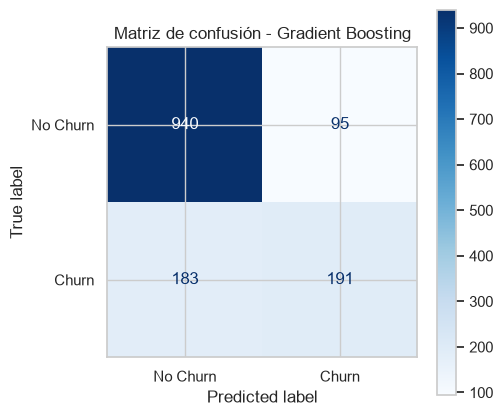

In [24]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["No Churn", "Churn"], cmap="Blues", ax=ax
)
ax.set_title(f"Matriz de confusión - {mejor_modelo_nombre}")
plt.show()

##### Interpretación de la Gráfica

Cada celda muestra cuántos clientes cayeron en esa combinación de predicción real vs. predicción del modelo, con colores más oscuros para valores más altos. La diagonal principal son los aciertos del modelo, mientras que las otras dos celdas son los errores.

El resultado muestra que el modelo predijo correctamente a 1131 clientes, de los cuáles 191 efectivamente abandonaron el servicio, mientras que los 940 restantes efectivamente se quedaron.

Para los 278 clientes restantes, el modelo predictivo tuvo 183 falsos negativos y 95 falsos positivos.

#### Curva ROC y curva Precision-Recall
Hasta ahora, todas las métricas se calcularon usando un umbral de decisión fijo de 0.5, donde si el modelo calcula que un cliente tiene más de 50% de probabilidad de irse, lo clasifica como "Churn"; si no, como "No Churn". Pero ese 0.5 es una elección arbitraria, no una regla obligatoria. Las curvas ROC y
Precision-Recall muestran cómo cambiaría el desempeño del modelo si se moviera ese umbral, sin necesidad de reentrenar nada.
 
- **Curva ROC:** en el eje horizontal muestra la tasa de falsos positivos, y en el vertical, la tasa de verdaderos positivos (recall), a medida que se recorren distintos umbrales. Entre más se pegue la curva hacia la esquina superior izquierda, mejor distingue el modelo entre ambas clases. El área bajo esta curva es justamente el ROC-AUC ya calculado (~ 0.84).

- **Curva Precision-Recall**: muestra cómo cambian precision y recall entre sí a medida que se mueve el umbral, donde normalmente, subir uno implica bajar el otro. En datasets desbalanceados como este, esta curva suele ser más informativa que la ROC, porque la ROC puede verse buena incluso cuando al modelo le cuesta trabajo con la clase minoritaria, mientras que la Precision-Recall refleja ese esfuerzo de forma más directa.

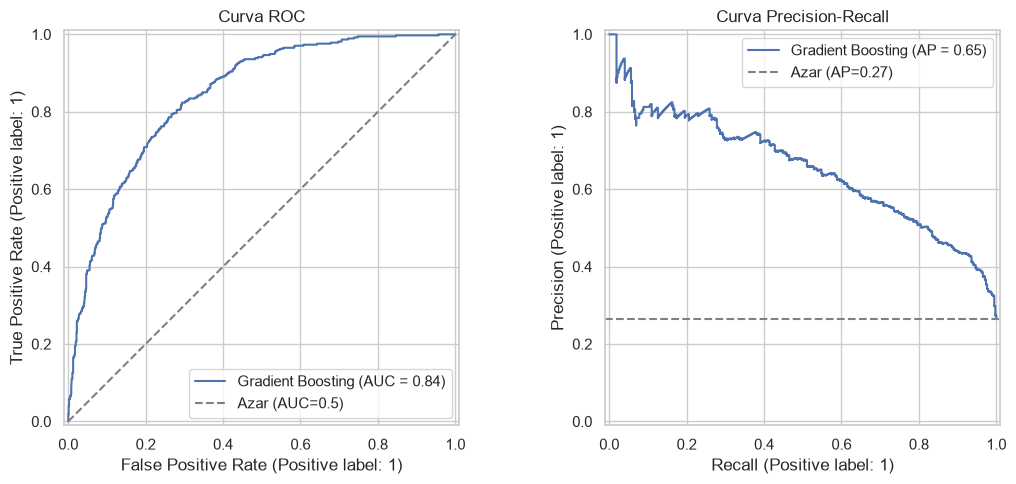

Average Precision (AP): 0.654


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0], name=mejor_modelo_nombre)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar (AUC=0.5)")
axes[0].set_title("Curva ROC")
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1], name=mejor_modelo_nombre)
tasa_positivos = y_test.mean()
axes[1].axhline(tasa_positivos, linestyle="--", color="gray", label=f"Azar (AP={tasa_positivos:.2f})")
axes[1].set_title("Curva Precision-Recall")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Average Precision (AP):", round(average_precision_score(y_test, y_proba), 3))

##### Interpretación de Ambas Curvas
La curva ROC muestra un despegue claro por encima de la línea diagonal de azar, consistente con el AUC de 0.84 ya calculado.

La curva Precision-Recall parte alta y desciende a medida que se relaja el umbral y el modelo empieza a marcar más casos como riesgo, ganando recall pero perdiendo algo de precisión. El **Average Precision (AP)** de aproximadamente 0.65 resume esa curva en un solo número, y está muy por encima de la línea base de azar (la proporción real de churn ~ 0.27), confirmando que el modelo aporta una capacidad predictiva real.

#### Importancia de Variables
Por último, dentro de la evaluación del modelo, es útil mirar qué variables está usando más el modelo para tomar sus decisiones. Esto sirve como una validación de sentido común, ya que si el modelo le diera mucho peso a variables que no deberían importar para nada, sería una señal de alerta. Si, en cambio, las variables más importantes tienen sentido de negocio, como el tipo de contrato o el tipo de servicio de internet, eso refuerza la confianza en que el modelo aprendió patrones reales y no ruido.

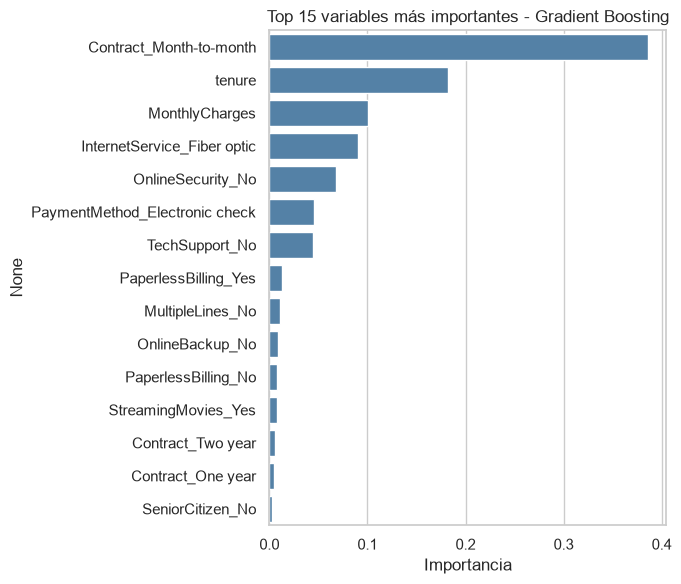

In [26]:
# Los modelos basados en arboles (Random Forest, Gradient Boosting, XGBoost) exponen
#'feature_importances_', mientras que la Regresion Logistica expone 'coef_' (sus coeficientes).

if hasattr(modelo_final, "feature_importances_"):
  importancias = pd.Series(modelo_final.feature_importances_, index=X_train.columns)

elif hasattr(modelo_final, "coef_"):
  importancias = pd.Series(np.abs(modelo_final.coef_[0]), index=X_train.columns)

else:
  importancias = None

if importancias is not None:
  top15 = importancias.sort_values(ascending=False).head(15)
  plt.figure(figsize=(7, 6))
  sns.barplot(x=top15.values, y=top15.index, color="steelblue")
  plt.title(f"Top 15 variables más importantes - {mejor_modelo_nombre}")
  plt.xlabel("Importancia")
  plt.tight_layout()
  plt.show()

##### Interpretación de los Resultados
En los primeros puestos se encuentran variables como `Contract_Month-to-month`, que indica que el tipo de contrato es mensual, `tenure`, que representa la antigüedad del cliente, `MonthlyCharges`, que representa el monto que se le cobra al cliente cada mes e `InternetService_Fiber optic` que indica que el tipo de servicio de internet es de fibra óptica. Estas variables son justamente las que se habían señalado como fuertemente relacionadas con el churn durante el análisis exploratorio, lo que indica una buena señal de consistencia en todo el proyecto.

### Análisis de Errores
---

Antes de realizar la interpretación general de los resultados, vale la pena mirar con más detalle qué tipo de clientes se le escapan al modelo. Para ello se comparan las características promedio de dos grupos: los clientes que sí se fueron y el modelo detectó correctamente (verdaderos positivos), contra los que sí se fueron pero el modelo no detectó (falsos negativos).

In [27]:
df_analisis = X_test.copy()
df_analisis["real"] = y_test.values
df_analisis["prediccion"] = y_pred

verdaderos_positivos = df_analisis[(df_analisis["real"] == 1) & (df_analisis["prediccion"] == 1)]
falsos_negativos = df_analisis[(df_analisis["real"] == 1) & (df_analisis["prediccion"] == 0)]

# Se eligen algunas variables clave para comparar el perfil promedio de ambos grupos
columnas_interes = [
  "tenure", "MonthlyCharges", "Contract_Month-to-month", "Contract_Two year",
  "InternetService_Fiber optic", "OnlineSecurity_Yes", "TechSupport_Yes",
]

comparacion_errores = pd.DataFrame({
  "Detectados correctamente (VP)": verdaderos_positivos[columnas_interes].mean(),
  "No detectados (FN)": falsos_negativos[columnas_interes].mean(),
}).round(3)

print(f"Verdaderos positivos: {len(verdaderos_positivos)} | Falsos negativos: {len(falsos_negativos)}")
comparacion_errores

Verdaderos positivos: 191 | Falsos negativos: 183


,Detectados correctamente (VP),No detectados (FN)
tenure,-1.024,-0.264
MonthlyCharges,0.396,0.118
Contract_Month-to-month,1.000,0.754
Contract_Two year,0.000,0.049
InternetService_Fiber optic,0.832,0.508
OnlineSecurity_Yes,0.058,0.273
TechSupport_Yes,0.037,0.290


#### Detalles a Tener en Cuenta
Para no malinterpretar la tabla se debe tener en cuenta que `tenure` y `MonthlyCharges` fueron estandarizadas durante el preprocesamiento, por lo que un valor negativo significa "por debajo del promedio general de todos los clientes" y uno positivo, "por encima". Las demás columnas son 0/1, así que su promedio se puede leer directamente como "porcentaje de clientes de ese grupo que cumple esa condición".

#### Interpretación de los Resultados
Los clientes correctamente detectados (VP) tienen un perfil de riesgo muy marcado: prácticamente el 100% tiene contrato mes a mes, más del 80% tiene fibra óptica y muy pocos cuentan con seguridad en línea o soporte técnico contratado.

Los falsos negativos, en cambio, tienen un perfil bastante menos marcado: contratos algo más largos, más presencia de servicios adicionales como `OnlineSecurity` y `TechSupport`, y una antigüedad más cercana al promedio general.

Esto indica que el modelo identifica muy bien los casos obvios de riesgo, pero le cuesta más detectar los casos de churn que no siguen ese patrón típico, es decir, clientes que, en apariencia, se ven relativamente estables, pero terminan yéndose de todas formas.

### Interpretación de los Resultados
---

#### ¿El Modelo Mejora al Modelo Base?
Sí, de forma clara y medible. El modelo base `DummyClassifier` con la estrategia `most_frequent` tiene recall y F1-score de **0** para la clase `Churn`, es decir, nunca identifica a ningún cliente en riesgo, aunque su *accuracy* (73.5%) parezca razonable a primera vista.

El modelo predictivo final `Gradient Boosting` alcanza un **F1 ≈ 0.58**, un **recall ≈ 0.51** y un **ROC-AUC ≈ 0.84**. En términos concretos pasa de "no detectar a nadie en riesgo" a "detectar correctamente a más de la mitad de los clientes que efectivamente cancelan el servicio". Esa diferencia es justamente el valor que aporta construir un modelo predictivo en vez de simplemente asumir que ningún cliente se va.

#### ¿La Métrica Obtenida es Razonable?
Sí. Un ROC-AUC de 0.84 se considera un desempeño bueno. Aunque no es espectacular, es sólido para un modelo de churn construido solo con variables estructurales del cliente como el tipo de contrato, servicios contratados, forma de pago, antigüedad, sin datos de comportamiento reciente como contactos al servicio al cliente o quejas registradas, que normalmente ayudarían a mejorar aún más estos números. Los resultados obtenidos no muestran indicios de sobreajuste ni de resultados sospechosamente perfectos, que de haber aparecido, habrían sido más bien una señal de alguna fuga de información pasada por alto.

Un hallazgo que vale la pena mencionar es que el ajuste de hiperparámetros por `GridSearchCV` no logró superar la configuración por defecto del modelo. Esto no invalida el proceso, confirma que, para este dataset, los valores por defecto de scikit-learn ya eran una elección acertada y deja abierta la posibilidad de ampliar la búsqueda en una futura iteración.


#### ¿Cuáles Fueron las Principales Dificultades?
- El desbalance de clases (~ 27% de casos positivos) obligó a elegir con cuidado qué métrica usar como criterio principal: el *accuracy*, que a primera vista parece la métrica más natural, resulta engañoso en este contexto y hubiera llevado a conclusiones equivocadas.

- Existe una tensión natural entre precision (67%) y recall (51%): las curvas ROC y Precision-Recall mostraron que sería posible mover el umbral de decisión para detectar más clientes en riesgo, pero eso aumentaría también las falsas alarmas. El umbral por defecto (0.5) usado en todo este notebook es un punto de partida razonable, pero no necesariamente el más óptimo.

- El análisis de errores reveló que los casos más difíciles de detectar no siguen el patrón "típico" de riesgo (contrato mensual, fibra óptica, sin soporte técnico), lo que pone un límite práctico a qué tan alto puede llegar el recall usando únicamente las variables disponibles en este dataset.

- La búsqueda de hiperparámetros es costosa en tiempo de cómputo, por lo que la grilla de valores probada se mantuvo en un rango razonable para que el notebook pudiera ejecutarse en un computador personal. Esto también implica que no se descarta que exista una mejor combinación fuera de ese rango.

#### ¿Qué Aspectos Podrían Mejorarse en Futuras Versiones?
- Probar técnicas específicas para el desbalance de clases, generando ejemplos sintéticos de la clase minoritaria, siempre ajustándolo únicamente sobre el conjunto de entrenamiento, para no introducir fuga de información hacia el conjunto de prueba.

- Ajustar el umbral de decisión de forma deliberada en vez de dejarlo fijo en 0.5, según el costo real que tenga para el negocio un falso negativo (perder un cliente sin haberlo detectado) frente a un falso positivo (invertir esfuerzo de retención en alguien que de todas formas no se iba a ir).

- Explorar combinaciones entre variables (por ejemplo, tipo de contrato junto con método de pago), que en la exploración de datos ya habían mostrado relación con el churn por separado.
